IMPORT LIBRARIES

In [6]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from plotnine import *  
print("All libraries imported successfully!")

All libraries imported successfully!


LOAD DATASET

In [7]:
df = pd.read_csv('fake_job_postings.csv')

DATAFRAME SUMMARY

In [8]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [10]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df.shape

(17880, 18)

In [12]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

In [13]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [14]:
df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

GETTING THE PERCENTAGE OR PROPORTION OF REAL AND FAKE JOB POSTINGS

In [15]:
df['fraudulent'].value_counts(normalize=True)  * 100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

ANALYSING REAL VS FAKE JOB COUNT 

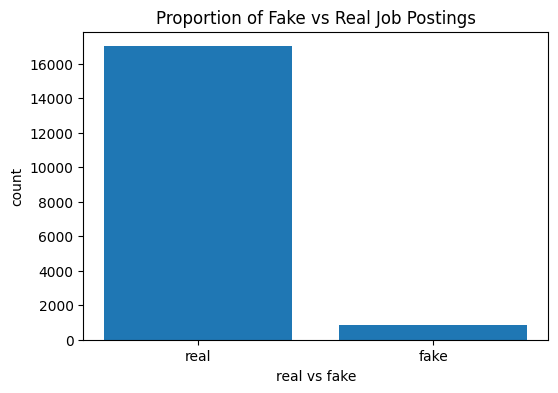

In [16]:
fraud_counts=df['fraudulent'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(['real','fake'],fraud_counts)
plt.title("Proportion of Fake vs Real Job Postings")
plt.xlabel("real vs fake")
plt.ylabel("count")
plt.show()

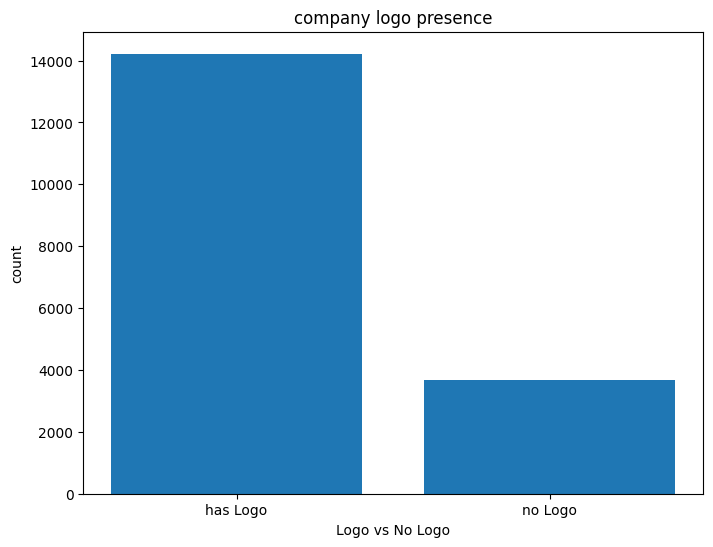

In [17]:
company_logo_counts = df['has_company_logo'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(['has Logo','no Logo'], company_logo_counts)
plt.title("company logo presence")
plt.xlabel("Logo vs No Logo")
plt.ylabel("count")
plt.show()

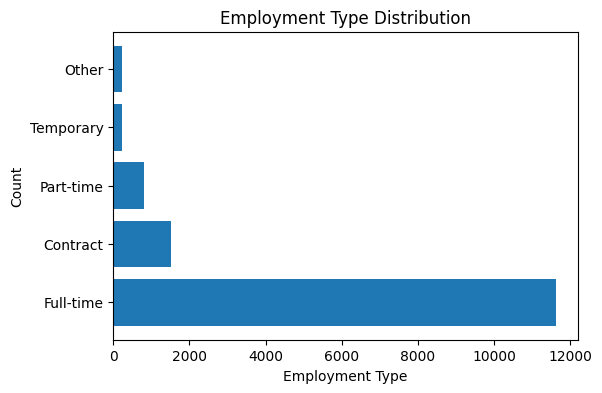

In [18]:
employment_type_counts= df['employment_type'].value_counts()
plt.figure(figsize=(6,4))
plt.barh(employment_type_counts.index, employment_type_counts.values)
plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.show()

In [19]:
print(employment_type_counts)

employment_type
Full-time    11620
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64


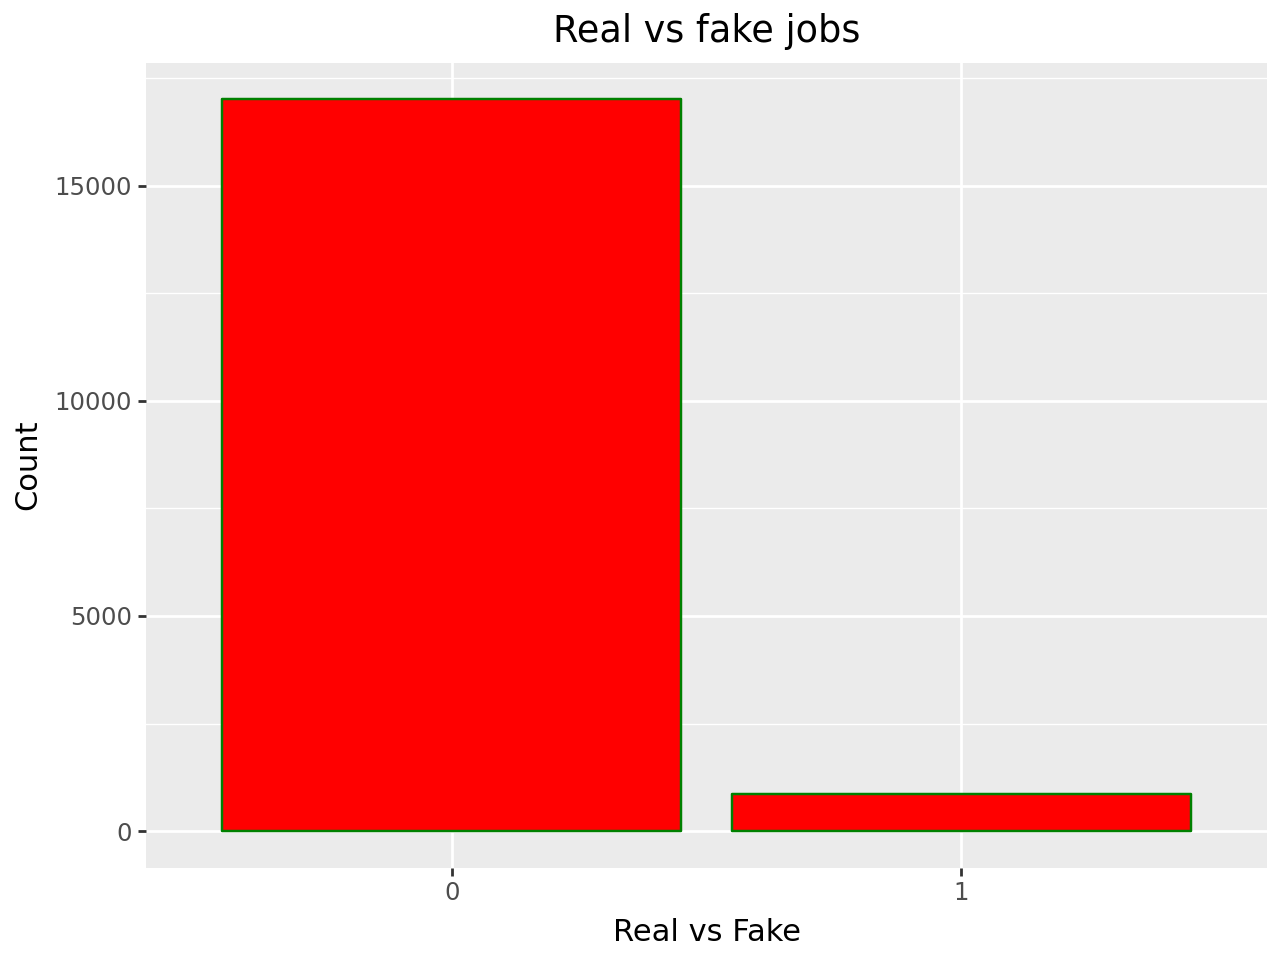

In [20]:
(ggplot(df,aes(x='factor(fraudulent)'))
 + geom_bar(fill='red',color='green')
 +labs(title="Real vs fake jobs",
        x="Real vs Fake",
        y="Count"
 )
)
       

LOOKING FOR NULL VALUES

In [21]:
df.isnull().sum()


job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

HANDLING MISSING VALUES

In [22]:
missing_percentage = ((df.isnull().sum()/len(df))*100)
print(missing_percentage.sort_values(ascending=False))

salary_range           83.959732
department             64.580537
required_education     45.329978
benefits               40.335570
required_experience    39.429530
function               36.101790
industry               27.421700
employment_type        19.412752
company_profile        18.501119
requirements           15.078300
location                1.935123
description             0.005593
title                   0.000000
job_id                  0.000000
telecommuting           0.000000
has_questions           0.000000
has_company_logo        0.000000
fraudulent              0.000000
dtype: float64


In [23]:
df.drop("salary_range", axis=1, inplace=True)

In [24]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'company_profile',
       'description', 'requirements', 'benefits', 'telecommuting',
       'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

REPLACING 'UNKNOWN' FOR TEXT NULL VALUES

In [25]:
df=df.fillna('unknown',inplace=True)

In [26]:
df.head()

,job_id,title,location,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,unknown,0,1,0,Other,Internship,unknown,unknown,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,unknown,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,unknown,0,1,0,unknown,unknown,unknown,unknown,unknown,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


MERGING TEXTUAL COLUMN FOR ONE NEAT FEATURE FOR ML

In [27]:
df['text']=( df['title'] + " " +
             df['description'] + " " +
             df['requirements']+ " " +
             df['benefits']+ " "
)
           

In [28]:
df.head()

,job_id,title,location,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text
0,1,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,unknown,0,1,0,Other,Internship,unknown,unknown,Marketing,0,"Marketing Intern Food52, a fast-growing, James..."
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,unknown,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production Orga...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,unknown,0,1,0,unknown,unknown,unknown,unknown,unknown,0,Commissioning Machinery Assistant (CMA) Our cl...
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,Account Executive - Washington DC THE COMPANY:...
4,5,Bill Review Manager,"US, FL, Fort Worth",unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,Bill Review Manager JOB TITLE: Itemization Rev...


In [29]:
df['text']=df['text'].str.lower()

IMPORTING REGULAR EXPRESSION FOR TEXT CLEANING

In [30]:
import re

In [31]:
df['text']=df['text'].apply(lambda x:re.sub (r'[^a-zA-z\s]',"",x))


In [32]:
print(df['text'])

0        marketing intern food a fastgrowing james bear...
1        customer service  cloud video production organ...
2        commissioning machinery assistant cma our clie...
3        account executive  washington dc the company e...
4        bill review manager job title itemization revi...
                               ...                        
17875    account director  distribution  just in case t...
17876    payroll accountant the payroll accountant will...
17877    project cost control staff engineer  cost cont...
17878    graphic designer nemsia studios is looking for...
17879    web application developers who are wevend is a...
Name: text, Length: 17880, dtype: str


INSTALLING NLTK FOR TOKENIZATION,STOPWORD AND NLP PREPROCESSING

In [33]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [34]:
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [39]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

TEXT PREPROCESSING FOR NLP

In [40]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'your', 'further', "you've", 'can', 'nor', 'were', "it's", 'at', 'my', 'myself', 'up', 'ma', 'what', 'yourself', "i'll", "they've", 'a', 'yourselves', 'are', 'the', 'himself', 'm', 'should', 'with', "she'll", "won't", 'yours', "they'd", 'by', 'against', 'd', 'no', "should've", 'as', 'mightn', "they're", 'until', "you'll", 'through', 'ours', 'not', 'do', "she'd", 'off', 'doing', "he'll", 'whom', 'does', 'such', 'him', 'hers', "i'd", 'if', 'other', "wouldn't", 'once', "it'd", 'under', 'again', 'won', "mustn't", "mightn't", 'from', 'i', 'both', 'more', 'or', 'same', 'than', 'between', 'very', 'is', 'herself', 'why', "aren't", "didn't", 'been', 'now', 'here', 'hadn', 'which', "you'd", 'some', 'how', 'shan', 'before', 'any', 'had', 'themselves', 'its', 'didn', 'in', 'am', "we'll", 'doesn', 'own', 'wasn', 'did', "it'll", 'me', 'haven', 'mustn', 'be', 'just', "we've", "he's", 'only', 'for', 'having', 'few', 'then', 'you', 'after', 'shouldn', 'ain', 'those', 'isn', 'will', "that'll", 'we', 'a

In [ ]:
df['text'] = df['text'].apply(
    lambda x: ' '.join(
        [word for word in word_tokenize(x) if word not in stop_words]
    )
)

In [43]:
df.head()

,job_id,title,location,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text
0,1,Marketing Intern,"US, NY, New York",Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,unknown,0,1,0,Other,Internship,unknown,unknown,Marketing,0,marketing intern food fastgrowing james beard ...
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,unknown,Marketing and Advertising,Customer Service,0,customer service cloud video production organi...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",unknown,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,unknown,0,1,0,unknown,unknown,unknown,unknown,unknown,0,commissioning machinery assistant cma client l...
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,account executive washington dc company esri e...
4,5,Bill Review Manager,"US, FL, Fort Worth",unknown,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,bill review manager job title itemization revi...


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
x=tfidf.fit_transform(df['text'])
y=df['fraudulent']
print(x.shape)
print(y.shape)

(17880, 5000)
(17880,)


In [46]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
   x,y,test_size=0.2,random_state=42 
)

In [47]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(14304, 5000)
(3576, 5000)
(14304,)
(3576,)


In [1]:
from sklearn.linear_model import LogisticRegression

In [2]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [3]:
model=LogisticRegression()